# Chapter 10: Bet Sizing

**AFML Ch. 10** -- Sizing positions based on prediction confidence.

When a classifier emits a probability, we must decide *how much* to bet.
A naive approach maps probability directly to position size, but more
sophisticated functions (sigmoid, power-law) allow us to control how
aggressively we scale into high-confidence predictions.

This notebook demonstrates:

- Sigmoid bet sizing (concave near the extremes)
- Power-law bet sizing (tuneable via exponent)
- Signal discretization (snapping continuous signals to a grid)
- Average active signals (combining overlapping bets)

In [1]:
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import pymlfinance
import pymlfinance.polars

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 15
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 15
plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['legend.fontsize'] = 13
np.random.seed(42)

## Sigmoid Bet Sizing

The sigmoid mapping converts a raw probability into a bet size in
`[-1, 1]`. The shape of the curve depends on `num_classes`: with 2
classes the inflection point is at 0.5, and with 3 classes it shifts
to account for the neutral class.

In [2]:
print(f"{'Probability':>12} {'Bet Size (2-class)':>20} {'Bet Size (3-class)':>20}")
for prob in [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]:
    size_2 = pymlfinance.backtesting.sigmoid_bet_size(prob, num_classes=2)
    size_3 = pymlfinance.backtesting.sigmoid_bet_size(prob, num_classes=3)
    print(f"{prob:>12.2f} {size_2:>20.4f} {size_3:>20.4f}")

 Probability   Bet Size (2-class)   Bet Size (3-class)
        0.00              -1.0000              -0.5000
        0.20              -0.6000              -0.2000
        0.40              -0.2000               0.1000
        0.50               0.0000               0.2500
        0.60               0.2000               0.4000
        0.80               0.6000               0.7000
        1.00               1.0000               1.0000


## Power Bet Sizing

The power-law mapping raises the normalised probability to an exponent.
Small exponents (< 1) are *concave* (aggressive at low confidence),
while large exponents (> 1) are *convex* (conservative until high
confidence).

In [3]:
print(f"{'Probability':>12} {'exp=0.5':>10} {'exp=1.0':>10} {'exp=2.0':>10} {'exp=3.0':>10}")
for prob in [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 1.0]:
    sizes = [pymlfinance.backtesting.power_bet_size(prob, 2, exp) for exp in [0.5, 1.0, 2.0, 3.0]]
    print(f"{prob:>12.2f} {sizes[0]:>10.4f} {sizes[1]:>10.4f} {sizes[2]:>10.4f} {sizes[3]:>10.4f}")

 Probability    exp=0.5    exp=1.0    exp=2.0    exp=3.0
        0.00    -1.0000    -1.0000    -1.0000    -1.0000
        0.20    -0.7746    -0.6000    -0.3600    -0.2160
        0.40    -0.4472    -0.2000    -0.0400    -0.0080
        0.50     0.0000     0.0000     0.0000     0.0000
        0.60     0.4472     0.2000     0.0400     0.0080
        0.80     0.7746     0.6000     0.3600     0.2160
        1.00     1.0000     1.0000     1.0000     1.0000


### Visualisation: Sigmoid vs Power Bet Sizing Curves

Plotting the full bet-size curves reveals the shape differences between
the sigmoid function and power-law mappings at various exponents.

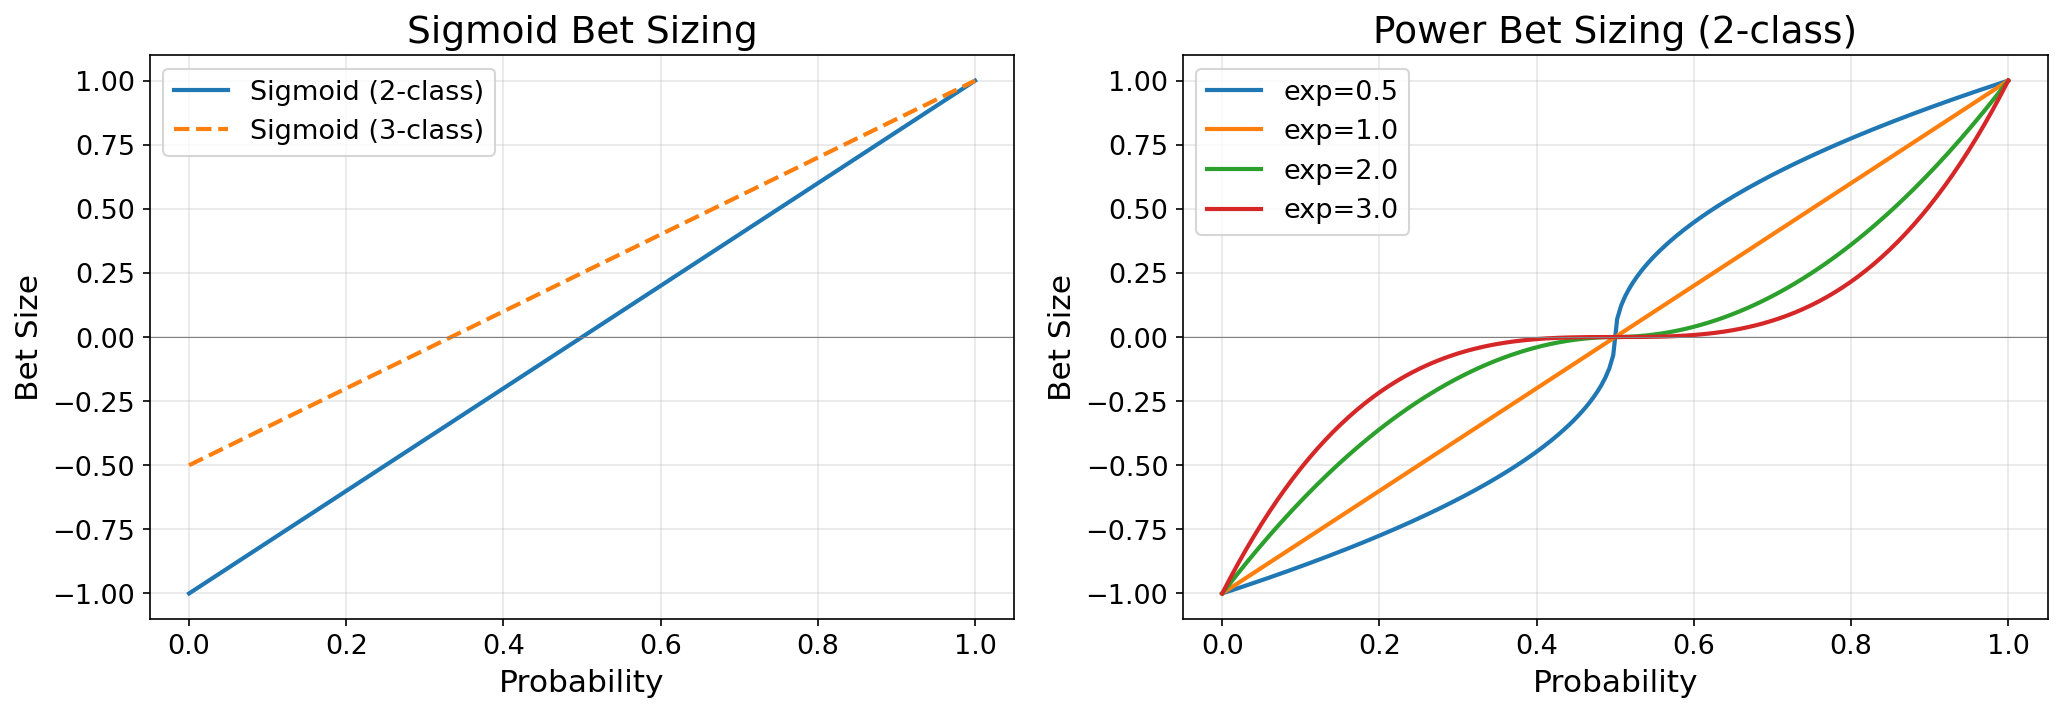

In [4]:
probs = np.linspace(0.0, 1.0, 200)

sigmoid_2 = [pymlfinance.backtesting.sigmoid_bet_size(p, num_classes=2) for p in probs]
sigmoid_3 = [pymlfinance.backtesting.sigmoid_bet_size(p, num_classes=3) for p in probs]
power_05 = [pymlfinance.backtesting.power_bet_size(p, 2, 0.5) for p in probs]
power_10 = [pymlfinance.backtesting.power_bet_size(p, 2, 1.0) for p in probs]
power_20 = [pymlfinance.backtesting.power_bet_size(p, 2, 2.0) for p in probs]
power_30 = [pymlfinance.backtesting.power_bet_size(p, 2, 3.0) for p in probs]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(probs, sigmoid_2, label="Sigmoid (2-class)", linewidth=2)
axes[0].plot(probs, sigmoid_3, label="Sigmoid (3-class)", linewidth=2, linestyle="--")
axes[0].set_xlabel("Probability")
axes[0].set_ylabel("Bet Size")
axes[0].set_title("Sigmoid Bet Sizing")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axhline(0, color="gray", linewidth=0.5)

axes[1].plot(probs, power_05, label="exp=0.5", linewidth=2)
axes[1].plot(probs, power_10, label="exp=1.0", linewidth=2)
axes[1].plot(probs, power_20, label="exp=2.0", linewidth=2)
axes[1].plot(probs, power_30, label="exp=3.0", linewidth=2)
axes[1].set_xlabel("Probability")
axes[1].set_ylabel("Bet Size")
axes[1].set_title("Power Bet Sizing (2-class)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].axhline(0, color="gray", linewidth=0.5)

plt.tight_layout()
plt.show()

## Signal Discretization

Continuous signals can be rounded to a fixed step size to reduce
turnover. A step of 0.1 means only ten discrete signal levels exist
between -1 and 1.

In [5]:
print(f"{'Continuous':>12} {'step=0.1':>10} {'step=0.2':>10} {'step=0.25':>10}")
for signal in [-0.73, -0.35, 0.0, 0.17, 0.42, 0.88]:
    d1 = pymlfinance.backtesting.discrete_signal(signal, 0.1)
    d2 = pymlfinance.backtesting.discrete_signal(signal, 0.2)
    d3 = pymlfinance.backtesting.discrete_signal(signal, 0.25)
    print(f"{signal:>12.2f} {d1:>10.2f} {d2:>10.2f} {d3:>10.2f}")

  Continuous   step=0.1   step=0.2  step=0.25
       -0.73      -0.70      -0.80      -0.75
       -0.35      -0.30      -0.40      -0.25
        0.00       0.00       0.00       0.00
        0.17       0.20       0.20       0.25
        0.42       0.40       0.40       0.50
        0.88       0.90       0.80       1.00


### Visualisation: Discrete Signal Step Plot

The step plot below shows how a continuous signal range maps onto
discrete levels for three different step sizes.

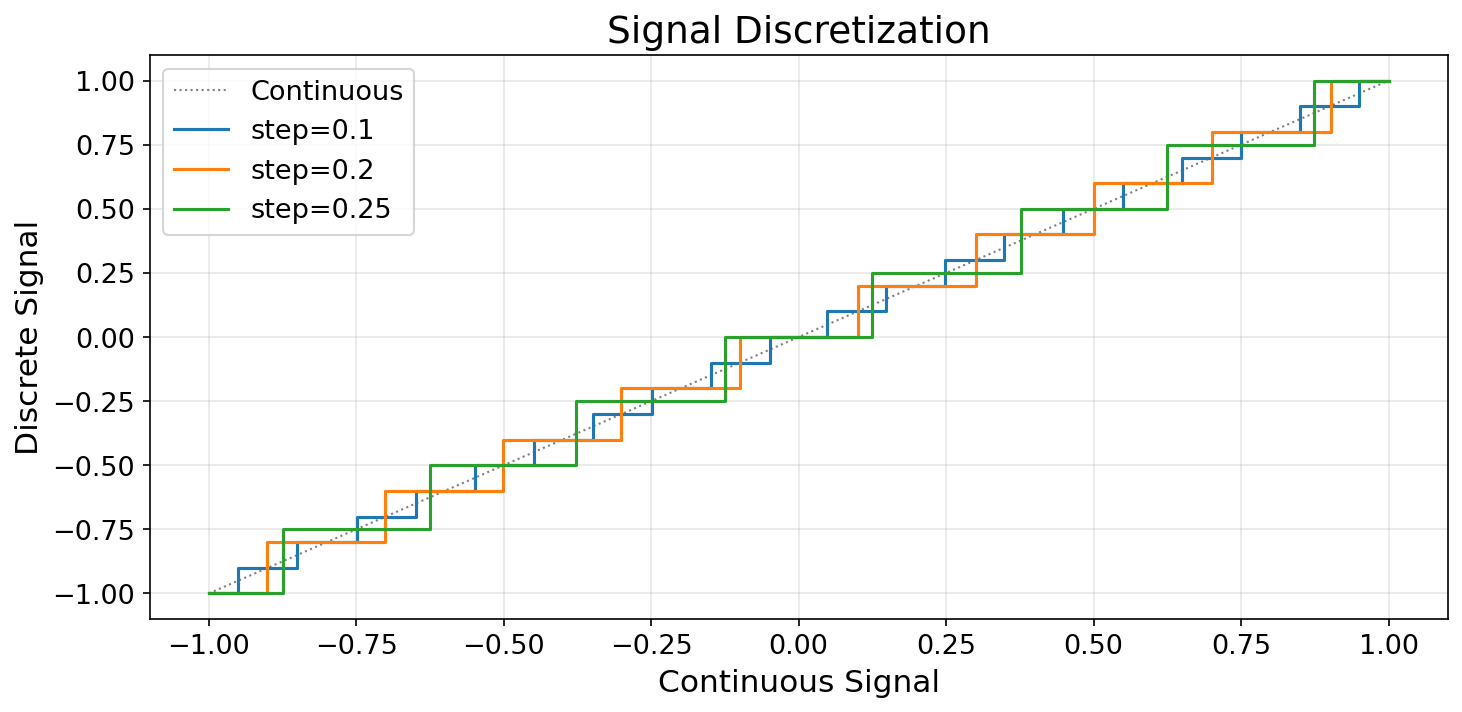

In [6]:
continuous = np.linspace(-1.0, 1.0, 500)
disc_01 = [pymlfinance.backtesting.discrete_signal(s, 0.1) for s in continuous]
disc_02 = [pymlfinance.backtesting.discrete_signal(s, 0.2) for s in continuous]
disc_025 = [pymlfinance.backtesting.discrete_signal(s, 0.25) for s in continuous]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(continuous, continuous, label="Continuous", color="gray", linewidth=1, linestyle=":")
ax.step(continuous, disc_01, label="step=0.1", linewidth=1.5, where="mid")
ax.step(continuous, disc_02, label="step=0.2", linewidth=1.5, where="mid")
ax.step(continuous, disc_025, label="step=0.25", linewidth=1.5, where="mid")
ax.set_xlabel("Continuous Signal")
ax.set_ylabel("Discrete Signal")
ax.set_title("Signal Discretization")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Average Active Signals

When multiple bets overlap in time, `avg_active_signals` computes the
time-weighted average signal at each bar. This is essential for
position management when signals have different lifetimes.

In [7]:
n_bars = 100
signals = [
    (0, 30, 0.5),
    (10, 40, -0.3),
    (25, 60, 0.7),
    (50, 80, -0.4),
    (70, 99, 0.6),
]
avg_signals = pymlfinance.backtesting.avg_active_signals(signals, n_bars)
print(f"{len(signals)} overlapping signals across {n_bars} bars")
print(f"Mean active signal: {np.mean(avg_signals):.4f}")
print(f"Max active signal:  {np.max(avg_signals):.4f}")
print(f"Min active signal:  {np.min(avg_signals):.4f}")

5 overlapping signals across 100 bars
Mean active signal: 0.2715
Max active signal:  0.7000
Min active signal:  -0.4000


### Visualisation: Active Signals Over Time

The plot below shows the average active signal at each bar. Shaded
regions indicate the individual signal lifetimes.

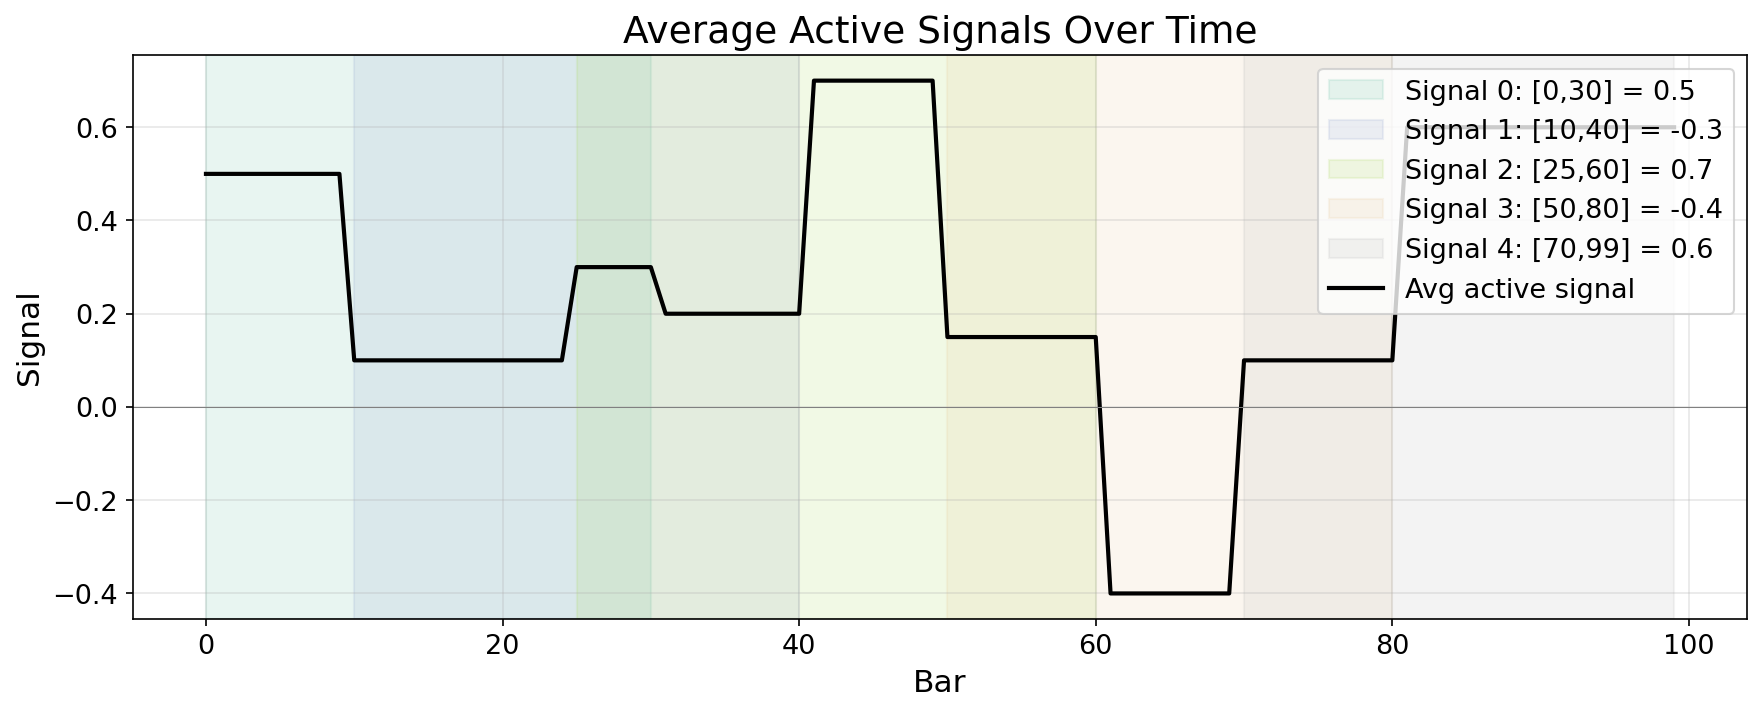

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))

colors = plt.cm.Set2(np.linspace(0, 1, len(signals)))
for i, (start, end, val) in enumerate(signals):
    ax.axvspan(start, end, alpha=0.15, color=colors[i],
               label=f"Signal {i}: [{start},{end}] = {val:.1f}")

ax.plot(range(n_bars), avg_signals, color="black", linewidth=2, label="Avg active signal")
ax.axhline(0, color="gray", linewidth=0.5)
ax.set_xlabel("Bar")
ax.set_ylabel("Signal")
ax.set_title("Average Active Signals Over Time")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Polars API

All bet-sizing functions are also available as Polars expressions via
the `.ml` namespace. This allows column-level operations on DataFrames.

In [9]:
probs = np.linspace(0.0, 1.0, 11)
df = pl.DataFrame({"probability": probs})
result = df.with_columns(
    pl.col("probability").ml.sigmoid_bet_size(num_classes=2).alias("sigmoid_bet"),
    pl.col("probability").ml.power_bet_size(num_classes=2, exponent=2.0).alias("power_bet"),
    pl.col("probability").ml.discrete_signal(step_size=0.1).alias("discrete"),
)
print(result)

shape: (11, 4)
┌─────────────┬─────────────┬───────────┬──────────┐
│ probability ┆ sigmoid_bet ┆ power_bet ┆ discrete │
│ ---         ┆ ---         ┆ ---       ┆ ---      │
│ f64         ┆ f64         ┆ f64       ┆ f64      │
╞═════════════╪═════════════╪═══════════╪══════════╡
│ 0.0         ┆ -1.0        ┆ -1.0      ┆ 0.0      │
│ 0.1         ┆ -0.8        ┆ -0.64     ┆ 0.1      │
│ 0.2         ┆ -0.6        ┆ -0.36     ┆ 0.2      │
│ 0.3         ┆ -0.4        ┆ -0.16     ┆ 0.3      │
│ 0.4         ┆ -0.2        ┆ -0.04     ┆ 0.4      │
│ …           ┆ …           ┆ …         ┆ …        │
│ 0.6         ┆ 0.2         ┆ 0.04      ┆ 0.6      │
│ 0.7         ┆ 0.4         ┆ 0.16      ┆ 0.7      │
│ 0.8         ┆ 0.6         ┆ 0.36      ┆ 0.8      │
│ 0.9         ┆ 0.8         ┆ 0.64      ┆ 0.9      │
│ 1.0         ┆ 1.0         ┆ 1.0       ┆ 1.0      │
└─────────────┴─────────────┴───────────┴──────────┘


## Exercises

1. Compare sigmoid vs power bet sizing curves with different exponents.
2. Create a simulation: feed random predictions through bet sizing and track P&L.
3. Explore how discretization step size affects portfolio turnover.